# 2_04 — Which individual proteases pass validation A, on held-out substrates?

*This notebook exists in two variants that differ only in which substrate table
they consume: the serum scope and the wider peptidase scope. The battery, the
split and the decision rule are identical, so the two verdict sets isolate what
the wider source adds.*

## Scope

`2_01` shows that the relation between the MEROPS window score and measured
kinetics exists across the panel. That is a statement about the panel: a pooled
correlation can be produced by two well covered enzymes while the rest
contribute nothing.

This notebook decides each protease separately, on the expanded substrate table
built in `2_05`, and evaluates every claim on substrates that were held out.

## The held-out split

### Why a random split would not do

Many substrates come in mutational series: `GFSPFRN`, `GFSPFAQ`, `GFSPFLQ`
differ at two positions. Splitting rows at random puts siblings on both sides,
and the test then measures interpolation inside a series rather than transfer
to a sequence the fit has not seen.

### How substrates are grouped

Substrates of one protease are clustered by sequence identity: any two
sequences at least 60% identical fall in the same cluster, by average-linkage
agglomeration on normalized edit distance. Whole clusters go to training or to
test, never both.

### When a split is impossible

A protease cannot be split meaningfully when its substrates form fewer than
three clusters, or when either side of the split would hold fewer than six
substrates. Six is the floor at which a permutation test can reach a
conventional significance level at all: five held-out points admit 120
orderings, so the smallest two-sided p-value they can produce is 2/120.

Such a protease is reported as `no_usable_holdout` with its in-sample
statistics only. That is a statement about the data, not about the enzyme.

## Why one split is not enough

A single cluster split produces one number, and that number moves when the
split moves. The effect is not small: during development one protease reported
a held-out correlation of 0.53 under one partition of its clusters and 0.80
under another, with **the same 67 substrates**, because the two runs happened
to draw different clusters into the test set. A verdict resting on one draw is
a statement about that draw.

### The repeated procedure

For each protease the split is drawn `N_SPLITS` times. Each draw follows the
same rule: whole clusters, the largest reserved for training, the test set
filled to the target share without overshooting. Each draw yields one held-out
correlation, and the protease is described by the **distribution** of those
correlations rather than by any one of them:

* the **median** held-out correlation, which is the point estimate;
* its 5th and 95th percentiles across splits, which is how much the answer
  depends on the partition;
* the **share of splits with a positive correlation**, which is the stability
  requirement. A protease whose sign flips between partitions has not shown
  that its ordering transfers, whatever its median is.

### Significance under the repeated procedure

The statistic being tested is the median across splits, so the null has to be
built for that statistic and not for a single correlation. The measurements of
the protease are permuted, and the permuted labels are pushed through **the
same stored splits**. Reusing the partitions isolates the effect of the pairing
from the effect of the partition: everything except the correspondence between
score and measurement is held fixed.

The p-value is the share of permutations whose median reaches the observed one.

### Splits do not depend on processing order

Each protease draws its splits from a generator seeded from its own MEROPS
code. Two runs of this notebook, and the same protease in the serum-scope and
peptidase-scope variants, therefore see identical partitions. Without this the
number of proteases processed earlier changes the random state and with it the
result, which is how the 0.53 against 0.80 discrepancy arose.

## What is fitted and what is not

The MEROPS score itself has no free parameters: it comes from the cleavage
records, not from these measurements. The **calibration** does have parameters,
the slope and intercept mapping score onto log10 $k_{cat}/K_M$, and those are
fitted on the training clusters only.

Two different claims are therefore evaluated, and they are reported separately:

* **ordering** — does the score rank held-out substrates correctly? Measured by
  the Spearman correlation on the test clusters.
* **calibration** — does the training fit predict held-out values? Measured by
  the mean absolute error on the test clusters against the baseline of
  predicting the training mean.

A score can order correctly and calibrate poorly. That combination is usable as
a ranking feature and not as a rate estimate.

## The battery

For each protease:

1. **Coverage** — distinct substrates, clusters, subsites populated, and which
   window convention they come from.
2. **Ordering on the held-out clusters** — the median Spearman correlation
   over `N_SPLITS` repeated cluster splits, with the spread across splits.
3. **Stability** — the share of splits on which the correlation is positive.
4. **Significance** — a permutation p-value for the median statistic, with the
   permuted labels pushed through the same stored splits.
5. **Correction for testing many proteases** — Benjamini-Hochberg q-values, so
   that the accepted set has a controlled share of false positives rather than
   each test having a controlled error alone.
6. **Calibration** — median over splits of the skill
   $1 - \\mathrm{MAE}_{\\mathrm{fit}} / \\mathrm{MAE}_{\\mathrm{baseline}}$, where
   the fit is trained on the training clusters and the baseline predicts the
   training mean. Zero means the fit is worth nothing beyond the mean.
7. **In-sample reference** — the correlation on all substrates, so that the
   drop to the held-out value is visible.

## The verdict

| Verdict | Condition | Meaning |
| --- | --- | --- |
| `accepted` | q < 0.05, positive median, positive on at least 90% of splits | the score orders unseen substrates of this enzyme, and the answer does not depend on the partition |
| `unstable` | q < 0.05 and positive median, but the sign flips on more than 10% of splits | significant on average, not reproducible across partitions |
| `not_supported` | splittable, q ≥ 0.05 | tested on held-out substrates and not demonstrated |
| `inverted` | q < 0.05 and negative median | the matrix orders substrates backwards |
| `no_usable_holdout` | fewer than 3 clusters, or fewer than 6 substrates on either side of the split | cannot be tested out of sample |
| `insufficient_evidence` | fewer than 3 substrates | a line through two points carries no information |

## Execution contract

**Inputs:** `results/2_06_substrate_table.csv`; `results/2_02_per_protease_verdicts.csv`; `results/0_03_hpa_abundance_per_protease.csv`; `data/merops/34_homo_sapiens/codes.json`.

**Outputs:** `results/2_04_substrate_set_expansion.csv`; `results/2_04_expansion_per_protease.csv`; `results/2_04_selected_protease_properties.csv`; `results/2_04_per_protease_verdicts.csv`; `results/2_04_substrate_splits.csv`; `results/2_04_extension_effect.csv`.

**Depends on:** `2_06` (a later notebook), `2_02`, `0_03`.

**Boundary:** Acceptance under these splits does not estimate a serum reaction rate.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import zlib

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import load_panel_metadata

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# Three substrates is the point at which a correlation carries any information at
# all; one or two define a line exactly and say nothing. Between three and the
# held-out threshold a protease is reported with its in-sample fit and no verdict,
# because the line may be stable without generalizing.
MIN_SUBSTRATES = 3
MIN_CLUSTERS = 3
# With fewer than six held-out substrates the permutation null is too coarse to
# reach any conventional significance level: five points admit 120 orderings, so
# the smallest attainable two-sided p-value is 2/120.
MIN_TEST_SUBSTRATES = 6
# Which substrate table this variant consumes, and the prefix it writes under.
# The two variants differ only in these two constants.
SOURCE_PREFIX = "2_06"
PREFIX = "2_04"
IDENTITY_THRESHOLD = 0.6
TEST_FRACTION = 0.3
# Repeated held-out evaluation. One split answers "what happened on this split";
# the distribution over many answers "what does this protease do", which is the
# question the verdict is about.
N_SPLITS = 100
N_PERMUTATIONS = 300
# A protease is accepted only if the ordering holds on this share of the splits.
# A significant median with an unstable sign is a result about one partition.
MIN_POSITIVE_SPLIT_FRACTION = 0.9
FALSE_DISCOVERY_RATE = 0.05
SEED = 20260920

In [3]:
names = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata(list(range(36)), merops_root=common.MEROPS_ROOT)
}

expanded = pd.read_csv(common.RESULTS_ROOT / f"{SOURCE_PREFIX}_substrate_table.csv")
print(f"substrate table: {SOURCE_PREFIX}_substrate_table.csv")
print(f"substrate table: {len(expanded)} (protease, substrate) pairs, "
      f"{expanded['merops_code'].nunique()} proteases")
print(expanded["window_convention"].value_counts().to_string())

substrate table: 2_06_substrate_table.csv
substrate table: 810 (protease, substrate) pairs, 84 proteases
window_convention
quenched    434
reporter    376


## What the quenched substrates added

The reporter-only population is the substrate set `2_01` worked with. Adding
the quenched substrates changes three things at once, and they are reported
separately because they are not the same gain:

* **more substrates**, which is what makes a held-out split possible at all;
* **more proteases**, including some that had no usable substrate before;
* **more of the window**, since a quenched substrate has residues on both sides
  of the cut while a reporter substrate has a leaving group where the prime
  subsites would be.

The third is the one that cannot be obtained by collecting more reporter
substrates: the prime half of every matrix is unreachable with that chemistry.

In [4]:
reporter_only = expanded.query("window_convention == 'reporter'")
expansion = pd.DataFrame(
    [
        {
            "quantity": "(protease, substrate) pairs",
            "reporter_only": len(reporter_only),
            "expanded": len(expanded),
        },
        {
            "quantity": "proteases with at least one substrate",
            "reporter_only": reporter_only["merops_code"].nunique(),
            "expanded": expanded["merops_code"].nunique(),
        },
        {
            "quantity": f"proteases with at least {MIN_SUBSTRATES} substrates",
            "reporter_only": int((reporter_only.groupby("merops_code").size() >= MIN_SUBSTRATES).sum()),
            "expanded": int((expanded.groupby("merops_code").size() >= MIN_SUBSTRATES).sum()),
        },
        {
            "quantity": "median subsites populated by the window",
            "reporter_only": float(reporter_only["n_observed_subsites"].median()),
            "expanded": float(expanded["n_observed_subsites"].median()),
        },
        {
            "quantity": "substrates reaching the full eight-subsite window",
            "reporter_only": int((reporter_only["n_observed_subsites"] == 8).sum()),
            "expanded": int((expanded["n_observed_subsites"] == 8).sum()),
        },
        {
            "quantity": "substrates populating any prime-side subsite",
            "reporter_only": int((reporter_only["n_observed_subsites"] > 4).sum()),
            "expanded": int((expanded["n_observed_subsites"] > 4).sum()),
        },
    ]
)
expansion["change"] = expansion.apply(
    lambda row: f"{row['expanded'] - row['reporter_only']:+g}", axis=1
)
print(expansion.to_string(index=False))

per_protease_gain = (
    expanded.pivot_table(
        index="merops_code", columns="window_convention", values="substrate_sequence", aggfunc="size"
    )
    .fillna(0)
    .astype(int)
)
per_protease_gain["total"] = per_protease_gain.sum(axis=1)
per_protease_gain["name"] = [names.get(code, "") for code in per_protease_gain.index]
per_protease_gain = per_protease_gain.sort_values("quenched", ascending=False)
print()
print("proteases gaining the most from the quenched substrates:")
print(per_protease_gain.query("quenched > 0").head(12).to_string())
print()
print("proteases that had no usable substrate before:")
gained_from_nothing = per_protease_gain.query("reporter == 0 and quenched > 0")
print(gained_from_nothing.to_string() if len(gained_from_nothing) else "  none")

common.save_result(expansion, f"{PREFIX}_substrate_set_expansion.csv")
common.save_result(per_protease_gain.reset_index(), f"{PREFIX}_expansion_per_protease.csv")

                                         quantity  reporter_only  expanded change
                      (protease, substrate) pairs          376.0     810.0   +434
            proteases with at least one substrate           72.0      84.0    +12
             proteases with at least 3 substrates           46.0      57.0    +11
          median subsites populated by the window            3.0       5.0     +2
substrates reaching the full eight-subsite window            0.0     141.0   +141
     substrates populating any prime-side subsite            0.0     434.0   +434

proteases gaining the most from the quenched substrates:
window_convention  quenched  reporter  total                                            name
merops_code                                                                                 
C01.032                  64         3     67                                     cathepsin L
S01.161                  57        10     67                  kallikrein-related peptidas

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_04_expansion_per_protease.csv')

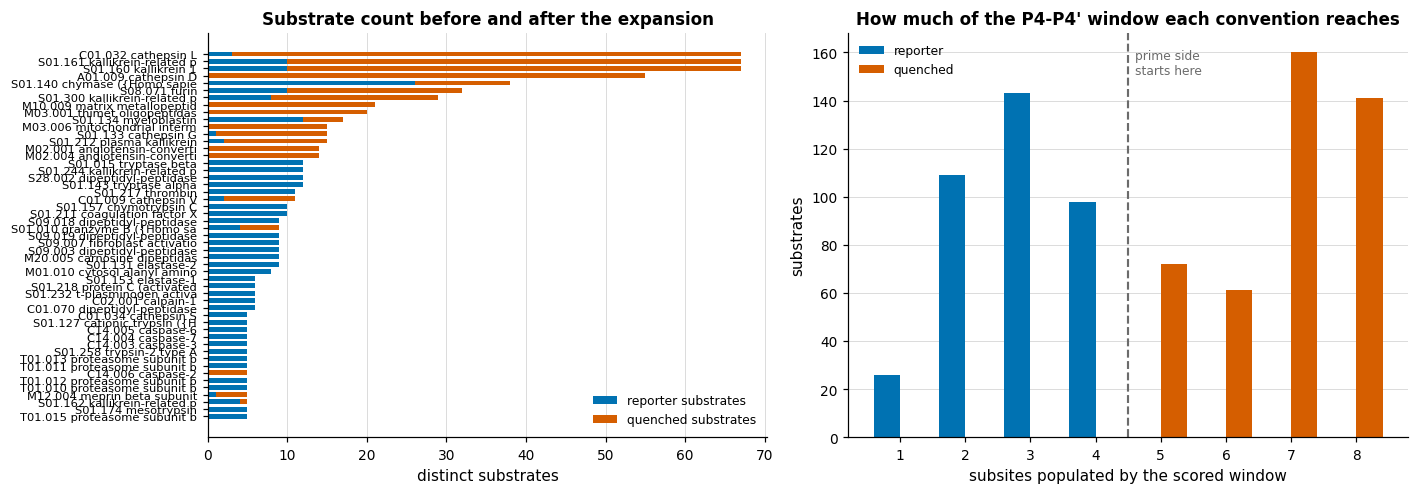

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

ax = axes[0]
gain_plot = per_protease_gain.query("total >= 5").sort_values("total")
positions = np.arange(len(gain_plot))
left = np.zeros(len(gain_plot))
for index, convention in enumerate(["reporter", "quenched"]):
    values = gain_plot[convention].to_numpy() if convention in gain_plot else np.zeros(len(gain_plot))
    ax.barh(
        positions,
        values,
        left=left,
        color=common.CATEGORICAL_COLORS[index],
        height=0.68,
        label=f"{convention} substrates",
    )
    left = left + values
ax.set_yticks(positions)
ax.set_yticklabels(
    [f"{code} {str(name)[:20]}" for code, name in zip(gain_plot.index, gain_plot["name"])],
    fontsize=7.5,
)
ax.set_xlabel("distinct substrates")
ax.set_title("Substrate count before and after the expansion")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", visible=False)

ax = axes[1]
bins = np.arange(0.5, 9.5, 1.0)
ax.hist(
    [reporter_only["n_observed_subsites"], expanded.query("window_convention == 'quenched'")["n_observed_subsites"]],
    bins=bins,
    color=[common.CATEGORICAL_COLORS[0], common.CATEGORICAL_COLORS[1]],
    label=["reporter", "quenched"],
)
ax.axvline(4.5, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.text(4.6, ax.get_ylim()[1] * 0.9, "prime side\nstarts here", fontsize=8, color=common.NEUTRAL)
ax.set_xlabel("subsites populated by the scored window")
ax.set_ylabel("substrates")
ax.set_title("How much of the P4-P4' window each convention reaches")
ax.legend(fontsize=8)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**Provenance**

`results/2_06_substrate_table.csv` is the BRENDA 2026.1 / MEROPS 2023 expanded source assembled by notebook `2_06`; code cells 4–6 separate `reporter` and `quenched` conventions and count unique substrates per MEROPS code. The figure uses the saved expansion tables `results/2_04_substrate_set_expansion.csv` and `2_04_expansion_per_protease.csv`. One BRENDA measurement can map to several codes, and one quenched-substrate score is a maximum over possible bonds, so added rows are not necessarily independent evidence. Inspect `window_convention`, `n_candidate_bonds`, and `shares_measurements_with_n_codes` in the substrate table.

> **Caveat.** For a FRET/quenched substrate with no resolved cleavage bond, `0_15_analysis_datasets.ipynb` cell 6 selects the maximum MEROPS score over admissible bonds (`argmax`). This selected maximum is a model-derived statistic, not a measured cut site; it can rise with peptide length and a sharper matrix even without better prediction. Report MEROPS–kinetics associations separately for `reporter` (known bond) and `quenched` (selected bond) conventions. Rows sharing one BRENDA measurement across MEROPS codes are dependent (`shares_measurements_with_n_codes`), so nominal N and permutation significance may be optimistic.


In [6]:
def cluster_sequences(sequences: list[str], identity_threshold: float) -> np.ndarray:
    """Group sequences so that similar ones never straddle a split.

    Distance is the edit distance normalized by the longer sequence, so two
    sequences at ``identity_threshold`` identity or above end in one cluster.

    :param sequences: Substrate sequences.
    :param identity_threshold: Minimum identity for two sequences to be grouped.
    :return: Cluster label per sequence, shape ``(n_sequences,)``.
    """

    if len(sequences) < 2:
        return np.zeros(len(sequences), dtype=int)
    distances = np.zeros((len(sequences), len(sequences)))
    for i, left in enumerate(sequences):
        for j in range(i + 1, len(sequences)):
            distance = Levenshtein.normalized_distance(left, sequences[j])
            distances[i, j] = distances[j, i] = distance
    linkage_matrix = linkage(squareform(distances, checks=False), method="average")
    return fcluster(linkage_matrix, t=1.0 - identity_threshold, criterion="distance")


def split_by_cluster(
    frame: pd.DataFrame, test_fraction: float, generator: np.random.Generator
) -> np.ndarray:
    """Assign whole clusters to training or to test.

    Whole clusters move together, so similar sequences never straddle the split.
    The largest cluster is always kept for training, and a cluster is added to
    test only if it does not push the test set past the target. Without that
    check a single dominant cluster would carry most of the substrates into test
    and leave the calibration fitted on a handful of points.

    :param frame: Substrates of one protease, carrying a ``cluster`` column.
    :param test_fraction: Target share of substrates in the test set.
    :param generator: Random generator.
    :return: ``"train"`` or ``"test"`` per row.
    """

    cluster_sizes = frame.groupby("cluster").size().sort_values(ascending=False)
    target = test_fraction * len(frame)
    minimum_training = (1.0 - test_fraction) * len(frame) * 0.8

    ## The largest cluster anchors the training set.
    reserved = int(cluster_sizes.index[0])
    candidates = [int(cluster) for cluster in cluster_sizes.index[1:]]
    generator.shuffle(candidates)

    test_clusters: set[int] = set()
    accumulated = 0
    for cluster in candidates:
        size = int(cluster_sizes[cluster])
        if accumulated + size > target:
            continue
        if len(frame) - accumulated - size < minimum_training:
            continue
        test_clusters.add(cluster)
        accumulated += size
    assert reserved not in test_clusters
    return np.where(frame["cluster"].isin(test_clusters), "test", "train")


def protease_generator(code: str) -> np.random.Generator:
    """Return a generator seeded from a protease code.

    Seeding from the code rather than from a shared stream makes the splits of a
    protease independent of how many proteases were processed before it, so the
    two scope variants and any rerun see identical partitions.

    :param code: MEROPS peptidase code.
    :return: Generator for this protease alone.
    """

    return np.random.default_rng(SEED + zlib.crc32(code.encode("utf-8")))


assignments = []
for code, group in expanded.groupby("merops_code"):
    group = group.drop_duplicates(subset="substrate_sequence").copy()
    group["cluster"] = cluster_sequences(group["substrate_sequence"].tolist(), IDENTITY_THRESHOLD)
    ## One split is stored on the table for the per-protease panels; the verdict
    ## uses the repeated splits drawn below.
    group["split"] = split_by_cluster(group, TEST_FRACTION, protease_generator(code))
    assignments.append(group)

split_table = pd.concat(assignments, ignore_index=True)

coverage = (
    split_table.groupby("merops_code")
    .agg(
        n_substrates=("substrate_sequence", "nunique"),
        n_clusters=("cluster", "nunique"),
        n_train=("split", lambda values: int((values == "train").sum())),
        n_test=("split", lambda values: int((values == "test").sum())),
        median_subsites=("n_observed_subsites", "median"),
        quenched=("window_convention", lambda values: int((values == "quenched").sum())),
        merops_cleavages=("merops_cleavages", "first"),
    )
    .reset_index()
    .sort_values("n_substrates", ascending=False)
)
coverage["name"] = coverage["merops_code"].map(names)
print(coverage.to_string(index=False))

merops_code  n_substrates  n_clusters  n_train  n_test  median_subsites  quenched  merops_cleavages                                           name
    C01.032            67           7       58       9              7.0        64              2956                                    cathepsin L
    S01.160            67          15       47      20              7.0        57                31                                   kallikrein 1
    S01.161            67          15       47      20              5.0        57                66                 kallikrein-related peptidase 2
    A01.009            55           4       49       6              8.0        55               923                                    cathepsin D
    S01.140            38           7       27      11              4.0        12               107                  chymase ({Homo sapiens}-type)
    S08.071            32          16       23       9              8.0        22               217                   

### Reading the coverage table

`n_clusters` is the quantity that decides whether a held-out test is possible.
A protease with 57 substrates in two clusters has less independent information
than one with 12 substrates in eight clusters, because the 57 are variants of
two parent sequences.

## The battery

Each protease is passed through the tests described at the top. Proteases that
cannot be split are still measured in sample, with their verdict fixed by the
structure of their substrate set.

In [7]:
def evaluate_split(
    frame: pd.DataFrame, assignment: np.ndarray, measured: np.ndarray
) -> tuple[float, float] | None:
    """Score one split: held-out ordering and held-out calibration skill.

    :param frame: Substrates of one protease.
    :param assignment: Boolean mask, ``True`` for the held-out rows.
    :param measured: Measured values to pair with the scores, permuted or not.
    :return: Tuple of held-out Spearman correlation and calibration skill, or
        ``None`` when the split does not meet the size requirements.
    """

    scores = frame["merops_score"].to_numpy()
    train_mask = ~assignment
    if assignment.sum() < MIN_TEST_SUBSTRATES or train_mask.sum() < MIN_TEST_SUBSTRATES:
        return None

    correlation = spearmanr(scores[assignment], measured[assignment]).statistic
    if not np.isfinite(correlation):
        return None

    ## Calibration is fitted on the training rows only and scored on the held-out
    ## ones, against the baseline of predicting the training mean.
    slope, intercept = np.polyfit(scores[train_mask], measured[train_mask], 1)
    predicted = slope * scores[assignment] + intercept
    fit_error = float(np.mean(np.abs(predicted - measured[assignment])))
    baseline_error = float(np.mean(np.abs(measured[train_mask].mean() - measured[assignment])))
    skill = 1.0 - fit_error / baseline_error if baseline_error > 0 else np.nan
    return float(correlation), float(skill)


records = []
for code, group in split_table.groupby("merops_code"):
    group = group.reset_index(drop=True)
    n_substrates = len(group)
    n_clusters = group["cluster"].nunique()
    measured = group["log10_kcat_over_km"].to_numpy()

    in_sample_rho = (
        spearmanr(group["merops_score"], measured).statistic if n_substrates >= 3 else np.nan
    )

    record = {
        "merops_code": code,
        "name": names.get(code, ""),
        "merops_cleavages": int(group["merops_cleavages"].iloc[0]),
        "n_substrates": n_substrates,
        "n_clusters": n_clusters,
        "median_subsites": float(group["n_observed_subsites"].median()),
        "n_quenched": int((group["window_convention"] == "quenched").sum()),
        "in_sample_rho": float(in_sample_rho) if np.isfinite(in_sample_rho) else np.nan,
        "n_valid_splits": 0,
        "median_test_size": np.nan,
        "test_rho_median": np.nan,
        "test_rho_p05": np.nan,
        "test_rho_p95": np.nan,
        "fraction_positive_splits": np.nan,
        "calibration_skill_median": np.nan,
        "test_permutation_p": np.nan,
    }

    if n_substrates >= MIN_SUBSTRATES and n_clusters >= MIN_CLUSTERS:
        ## Draw and store the partitions once, so that the observed statistic and
        ## its null are evaluated on exactly the same splits.
        generator = protease_generator(code)
        stored_splits = []
        for _ in range(N_SPLITS):
            assignment = split_by_cluster(group, TEST_FRACTION, generator) == "test"
            if assignment.sum() >= MIN_TEST_SUBSTRATES and (~assignment).sum() >= MIN_TEST_SUBSTRATES:
                stored_splits.append(assignment)

        observed = [evaluate_split(group, assignment, measured) for assignment in stored_splits]
        observed = [item for item in observed if item is not None]

        if len(observed) >= max(10, N_SPLITS // 10):
            correlations = np.array([item[0] for item in observed])
            skills = np.array([item[1] for item in observed])
            observed_median = float(np.median(correlations))

            ## Null for the median statistic: permute the labels, push them
            ## through the same stored partitions, take the same median.
            null_medians = []
            for _ in range(N_PERMUTATIONS):
                permuted = generator.permutation(measured)
                values = [
                    evaluate_split(group, assignment, permuted) for assignment in stored_splits
                ]
                values = [item[0] for item in values if item is not None]
                if values:
                    null_medians.append(float(np.median(values)))
            null_medians = np.array(null_medians)

            record.update(
                {
                    "n_valid_splits": len(observed),
                    "median_test_size": float(np.median([a.sum() for a in stored_splits])),
                    "test_rho_median": observed_median,
                    "test_rho_p05": float(np.percentile(correlations, 5)),
                    "test_rho_p95": float(np.percentile(correlations, 95)),
                    "fraction_positive_splits": float((correlations > 0).mean()),
                    "calibration_skill_median": float(np.nanmedian(skills)),
                    "test_permutation_p": (
                        float((np.abs(null_medians) >= abs(observed_median)).mean())
                        if len(null_medians)
                        else np.nan
                    ),
                }
            )

    records.append(record)

verdicts = pd.DataFrame(records).sort_values("n_substrates", ascending=False).reset_index(drop=True)

tested = verdicts["test_permutation_p"].notna()
verdicts["q_value"] = np.nan
if tested.any():
    _, q_values, _, _ = multipletests(
        verdicts.loc[tested, "test_permutation_p"], alpha=FALSE_DISCOVERY_RATE, method="fdr_bh"
    )
    verdicts.loc[tested, "q_value"] = q_values

significant = verdicts["q_value"] < FALSE_DISCOVERY_RATE
positive = verdicts["test_rho_median"] > 0
stable = verdicts["fraction_positive_splits"] >= MIN_POSITIVE_SPLIT_FRACTION

verdicts["verdict"] = np.select(
    [
        verdicts["n_substrates"] < MIN_SUBSTRATES,
        ~tested,
        significant & positive & stable,
        significant & positive & ~stable,
        significant & (verdicts["test_rho_median"] < 0),
    ],
    ["insufficient_evidence", "no_usable_holdout", "accepted", "unstable", "inverted"],
    default="not_supported",
)

print(
    verdicts[
        [
            "merops_code", "name", "n_substrates", "n_clusters", "n_valid_splits",
            "median_subsites", "in_sample_rho", "test_rho_median", "test_rho_p05",
            "test_rho_p95", "fraction_positive_splits", "test_permutation_p", "q_value",
            "calibration_skill_median", "verdict",
        ]
    ].round(3).to_string(index=False)
)
print()
print(verdicts["verdict"].value_counts().to_string())

merops_code                                           name  n_substrates  n_clusters  n_valid_splits  median_subsites  in_sample_rho  test_rho_median  test_rho_p05  test_rho_p95  fraction_positive_splits  test_permutation_p  q_value  calibration_skill_median               verdict
    C01.032                                    cathepsin L            67           7             100              7.0          0.543            0.628         0.628         0.628                      1.00               0.087    0.202                     0.296         not_supported
    S01.160                                   kallikrein 1            67          15             100              7.0          0.519            0.756         0.558         0.877                      1.00               0.000    0.000                     0.137              accepted
    S01.161                 kallikrein-related peptidase 2            67          15             100              5.0         -0.176           -0.009        

### Reading the verdict table

* `in_sample_rho` — the correlation on all substrates, comparable with `2_01`.
* `train_rho` and `test_rho` — the same quantity on the training and the
  held-out clusters. A large drop between them is the signature of a relation
  that does not transfer across sequence families.
* `test_permutation_p` and `q_value` — significance on the held-out clusters,
  before and after correcting for the number of proteases tested.
* `calibration_skill` — how much the training fit improves the prediction of
  held-out values over predicting the training mean. Zero is no improvement.
* `median_subsites` — with quenched substrates this reaches seven, meaning the
  whole $P_4 \\ldots P_4'$ window is used, against three for reporter-only
  proteases.

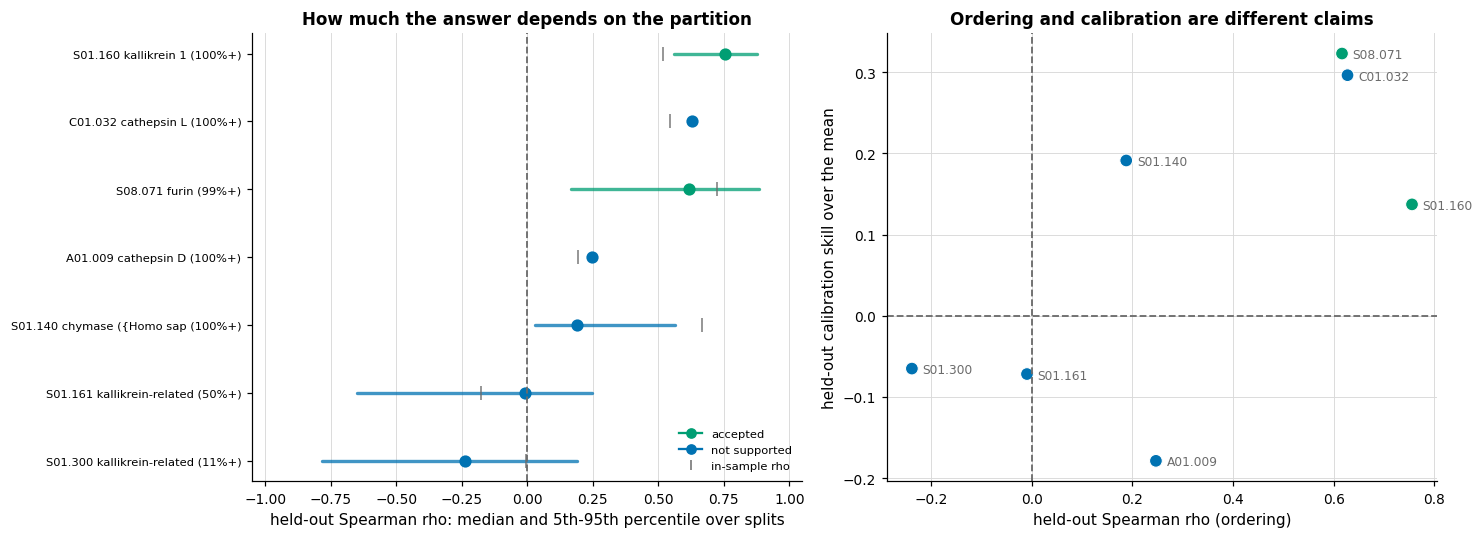

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))
verdict_colour = {
    "accepted": common.CATEGORICAL_COLORS[2],
    "unstable": common.CATEGORICAL_COLORS[4],
    "inverted": common.CATEGORICAL_COLORS[1],
    "not_supported": common.CATEGORICAL_COLORS[0],
    "no_usable_holdout": common.CATEGORICAL_COLORS[3],
    "insufficient_evidence": common.NEUTRAL,
}

ax = axes[0]
comparable = verdicts.dropna(subset=["test_rho_median"]).sort_values("test_rho_median").reset_index(drop=True)
for position, row in comparable.iterrows():
    colour = verdict_colour[row["verdict"]]
    ax.plot(
        [row["test_rho_p05"], row["test_rho_p95"]],
        [position, position],
        color=colour,
        linewidth=2.2,
        alpha=0.75,
        solid_capstyle="round",
    )
    ax.plot(row["test_rho_median"], position, marker="o", markersize=7, color=colour)
    ax.plot(
        row["in_sample_rho"], position, marker="|", markersize=9, color=common.NEUTRAL, alpha=0.9
    )
ax.axvline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.2)
ax.set_yticks(comparable.index)
ax.set_yticklabels(
    [
        f"{row.merops_code} {str(row.name)[:18]} ({row.fraction_positive_splits:.0%}+)"
        for row in comparable.itertuples()
    ],
    fontsize=7.5,
)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("held-out Spearman rho: median and 5th-95th percentile over splits")
ax.set_title("How much the answer depends on the partition")
ax.grid(axis="y", visible=False)
handles = [
    plt.Line2D([], [], marker="o", linestyle="-", color=colour, label=verdict.replace("_", " "))
    for verdict, colour in verdict_colour.items()
    if verdict in set(comparable["verdict"])
] + [plt.Line2D([], [], marker="|", linestyle="", color=common.NEUTRAL, label="in-sample rho")]
ax.legend(handles=handles, loc="lower right", fontsize=7.5)

ax = axes[1]
ax.scatter(
    comparable["test_rho_median"],
    comparable["calibration_skill_median"],
    s=70,
    c=[verdict_colour[value] for value in comparable["verdict"]],
    edgecolor="white",
    linewidth=0.7,
)
for _, row in comparable.iterrows():
    ax.annotate(
        row["merops_code"],
        (row["test_rho_median"], row["calibration_skill_median"]),
        textcoords="offset points",
        xytext=(7, -3),
        fontsize=8,
        color=common.NEUTRAL,
    )
ax.axhline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.2)
ax.axvline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.2)
ax.set_xlabel("held-out Spearman rho (ordering)")
ax.set_ylabel("held-out calibration skill over the mean")
ax.set_title("Ordering and calibration are different claims")
fig.tight_layout()
plt.show()

## One panel per protease

Training substrates as open markers, held-out substrates as filled ones, and
the calibration line fitted on training only. The subtitle carries the held-out
correlation, the corrected q-value and the verdict.

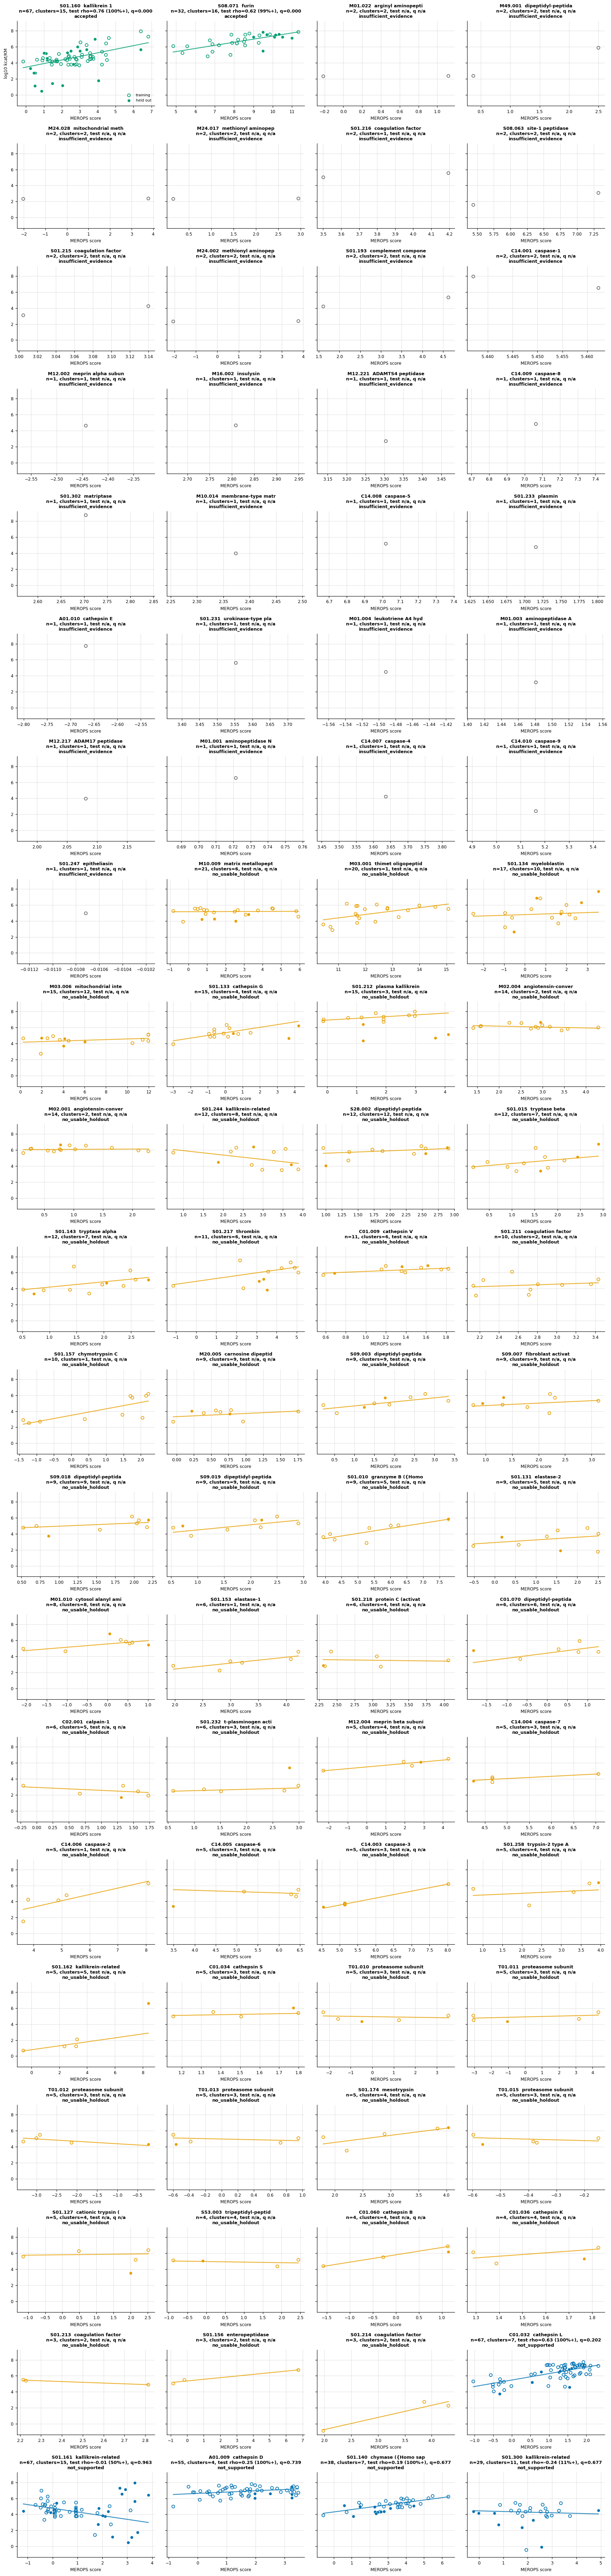

In [9]:
ordered = verdicts.sort_values(["verdict", "n_substrates"], ascending=[True, False])
n_columns = 4
n_rows = int(np.ceil(len(ordered) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(4.0 * n_columns, 3.2 * n_rows), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, ordered.iterrows()):
    group = split_table[split_table["merops_code"] == row["merops_code"]]
    colour = verdict_colour[row["verdict"]]
    train = group.query("split == 'train'")
    test = group.query("split == 'test'")
    ax.scatter(
        train["merops_score"], train["log10_kcat_over_km"],
        s=30, facecolor="none", edgecolor=colour, linewidth=1.2, label="training",
    )
    ax.scatter(
        test["merops_score"], test["log10_kcat_over_km"],
        s=34, color=colour, edgecolor="white", linewidth=0.5, label="held out",
    )
    if len(train) >= 3:
        fit = np.polyfit(train["merops_score"], train["log10_kcat_over_km"], 1)
        grid = np.linspace(group["merops_score"].min(), group["merops_score"].max(), 20)
        ax.plot(grid, np.polyval(fit, grid), color=colour, linewidth=1.6, alpha=0.8)
    q_text = "q n/a" if not np.isfinite(row["q_value"]) else f"q={row['q_value']:.3f}"
    test_text = (
        "test n/a"
        if not np.isfinite(row["test_rho_median"])
        else f"test rho={row['test_rho_median']:.2f} ({row['fraction_positive_splits']:.0%}+)"
    )
    ax.set_title(
        f"{row['merops_code']}  {str(row['name'])[:18]}\n"
        f"n={int(row['n_substrates'])}, clusters={int(row['n_clusters'])}, {test_text}, {q_text}\n"
        f"{row['verdict']}",
        fontsize=8.5,
    )
    ax.tick_params(labelsize=8)
    ax.set_xlabel("MEROPS score", fontsize=8)

axes[0].set_ylabel("log10 kcat/KM", fontsize=8)
axes[0].legend(fontsize=7, loc="lower right")
for ax in axes[len(ordered):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## What the accepted set supports

An accepted protease is one whose held-out substrates the score orders
correctly, after correction for the number of proteases tested. That supports
using the score as a ranking feature for that enzyme.

The calibration skill states separately whether the score can be turned into a
rate estimate. The two are reported together because a positive ordering with
zero calibration skill is common and means the score ranks without predicting.

In [10]:
accepted = verdicts.query("verdict == 'accepted'")
print(f"accepted on held-out substrates: {len(accepted)} of {int(tested.sum())} testable "
      f"({len(verdicts)} proteases in the table)")
if len(accepted):
    print()
    print(
        accepted[
            ["merops_code", "name", "n_substrates", "n_clusters", "n_valid_splits",
             "median_test_size", "test_rho_median", "test_rho_p05", "test_rho_p95",
             "fraction_positive_splits", "q_value", "calibration_skill_median"]
        ].round(3).to_string(index=False)
    )

for verdict in ["not_supported", "no_usable_holdout", "insufficient_evidence", "inverted"]:
    subset = verdicts.query("verdict == @verdict")
    if not len(subset):
        continue
    print()
    print(f"{verdict}: {len(subset)}")
    print(
        subset[["merops_code", "name", "n_substrates", "n_clusters", "in_sample_rho", "test_rho_median", "q_value"]]
        .round(3).to_string(index=False)
    )

print()
print("effect of the expanded substrate set on window coverage:")
print(
    split_table.groupby("window_convention")["n_observed_subsites"]
    .agg(["size", "median", "max"])
    .to_string()
)

accepted on held-out substrates: 2 of 7 testable (84 proteases in the table)

merops_code         name  n_substrates  n_clusters  n_valid_splits  median_test_size  test_rho_median  test_rho_p05  test_rho_p95  fraction_positive_splits  q_value  calibration_skill_median
    S01.160 kallikrein 1            67          15             100              20.0            0.756         0.558         0.877                      1.00      0.0                     0.137
    S08.071        furin            32          16             100               9.0            0.617         0.167         0.883                      0.99      0.0                     0.323

not_supported: 5
merops_code                           name  n_substrates  n_clusters  in_sample_rho  test_rho_median  q_value
    C01.032                    cathepsin L            67           7          0.543            0.628    0.202
    S01.161 kallikrein-related peptidase 2            67          15         -0.176           -0.009    0.963
 

## Properties of the proteases the data selected

The proteases reaching this notebook were selected by how many substrates
happen to have been measured, which is a property of the literature. Whether
they are also the proteases that matter in serum is a separate question, and
the abundance prior from `0_03_serum_peptidase_abundance.ipynb` is the only
evidence available for it.

The figure repeats the abundance ranking of the whole serum panel and marks the
tested proteases in black. If the marked entries sat at the bottom of the
ranking, the analysis would be describing enzymes that are barely present.

The values remain abundance, not activity: a circulating protease can be a
zymogen or an inhibitor complex, and the two HPA methods disagree by a median
of half a log10 unit. The ranking is a coarse ordering, not a concentration.

In [11]:
abundance = pd.read_csv(common.RESULTS_ROOT / "0_03_hpa_abundance_per_protease.csv")
abundance["best_estimate_pg_per_l"] = abundance[["ms_pg_per_l", "immunoassay_pg_per_l"]].max(axis=1)
measured_panel = abundance.dropna(subset=["best_estimate_pg_per_l"]).sort_values(
    "best_estimate_pg_per_l"
).reset_index(drop=True)
measured_panel["abundance_rank"] = np.arange(len(measured_panel), 0, -1)

## Every protease that reached this notebook carries a verdict, including the
## ones with too few substrates to test. All of them are shown, coloured by that
## verdict, so that a data-poor enzyme is visibly data-poor rather than absent.
verdict_by_code = dict(zip(verdicts["merops_code"], verdicts["verdict"]))
measured_panel["verdict"] = measured_panel["merops_code"].map(verdict_by_code)
measured_panel["is_tested"] = measured_panel["verdict"].notna()

selected = (
    verdicts.merge(
        measured_panel[["merops_code", "gene_name", "best_estimate_pg_per_l", "abundance_rank"]],
        on="merops_code",
        how="left",
    )
    .sort_values("best_estimate_pg_per_l", ascending=False)
)
selected["abundance_percentile"] = 1.0 - selected["abundance_rank"] / len(measured_panel)

print(f"serum panel proteases with an abundance value: {len(measured_panel)} of {len(abundance)}")
print(f"tested proteases among them: {int(measured_panel['is_tested'].sum())}")
print()
print(
    selected[
        ["merops_code", "name", "gene_name", "best_estimate_pg_per_l", "abundance_rank",
         "abundance_percentile", "n_substrates", "median_subsites", "test_rho_median", "verdict"]
    ].round(3).to_string(index=False)
)
print()
covered = selected["best_estimate_pg_per_l"].notna()
print(f"tested proteases in the top third of the abundance ranking: "
      f"{int((selected.loc[covered, 'abundance_percentile'] >= 2 / 3).sum())} of {int(covered.sum())}")
print(f"median abundance percentile of the tested set: "
      f"{selected.loc[covered, 'abundance_percentile'].median():.2f} "
      "(0.5 would mean the tested set is a random slice of the panel)")

common.save_result(selected, f"{PREFIX}_selected_protease_properties.csv")

serum panel proteases with an abundance value: 42 of 54
tested proteases among them: 22

merops_code                                           name gene_name  best_estimate_pg_per_l  abundance_rank  abundance_percentile  n_substrates  median_subsites  test_rho_median               verdict
    S01.233                                        plasmin       PLG            1.400000e+11             1.0                 0.976             1              3.0              NaN insufficient_evidence
    S01.217                                       thrombin        F2            1.100000e+11             2.0                 0.952            11              3.0              NaN     no_usable_holdout
    S01.193             complement component activated C1s       C1S            9.300000e+10             3.0                 0.929             2              3.5              NaN insufficient_evidence
    S01.212                              plasma kallikrein     KLKB1            2.900000e+10             7.

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_04_selected_protease_properties.csv')

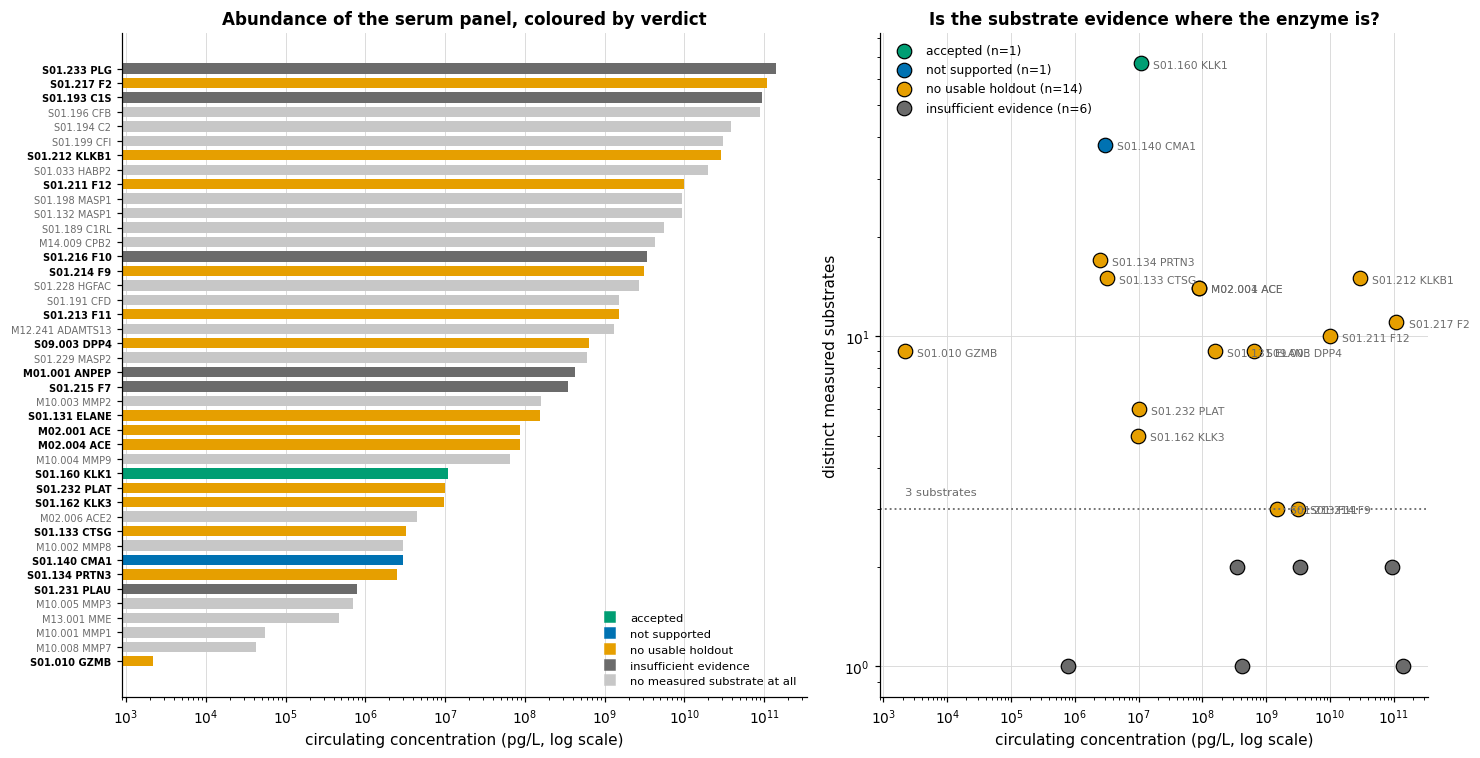

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 7.0), gridspec_kw={"width_ratios": [1.25, 1]})

NOT_IN_ANALYSIS = "#c7c7c7"

ax = axes[0]
bar_colours = [
    verdict_colour[verdict] if isinstance(verdict, str) else NOT_IN_ANALYSIS
    for verdict in measured_panel["verdict"]
]
ax.barh(
    range(len(measured_panel)),
    measured_panel["best_estimate_pg_per_l"],
    color=bar_colours,
    height=0.72,
)
ax.set_yticks(range(len(measured_panel)))
ax.set_yticklabels(
    [f"{row.merops_code} {row.gene_name}" for row in measured_panel.itertuples()], fontsize=6.5
)
for tick, flag in zip(ax.get_yticklabels(), measured_panel["is_tested"]):
    tick.set_color("black" if flag else common.NEUTRAL)
    tick.set_fontweight("bold" if flag else "normal")
ax.set_xscale("log")
ax.set_xlabel("circulating concentration (pg/L, log scale)")
ax.set_title("Abundance of the serum panel, coloured by verdict")
ax.grid(axis="y", visible=False)
handles = [
    plt.Line2D([], [], marker="s", linestyle="", color=colour, label=verdict.replace("_", " "))
    for verdict, colour in verdict_colour.items()
    if verdict in set(measured_panel["verdict"].dropna())
] + [
    plt.Line2D([], [], marker="s", linestyle="", color=NOT_IN_ANALYSIS,
               label="no measured substrate at all")
]
ax.legend(handles=handles, loc="lower right", fontsize=7.5)

ax = axes[1]
plotted = selected.dropna(subset=["best_estimate_pg_per_l"])
for verdict, colour in verdict_colour.items():
    subset = plotted[plotted["verdict"] == verdict]
    if not len(subset):
        continue
    ax.scatter(
        subset["best_estimate_pg_per_l"],
        subset["n_substrates"],
        s=90,
        color=colour,
        edgecolor="black",
        linewidth=0.8,
        label=f"{verdict.replace('_', ' ')} (n={len(subset)})",
    )
## Labelling every point makes the low-substrate cluster unreadable, so only the
## proteases carrying a verdict beyond "insufficient evidence" are named.
for _, row in plotted.query("verdict != 'insufficient_evidence'").iterrows():
    ax.annotate(
        f"{row['merops_code']} {row['gene_name']}",
        (row["best_estimate_pg_per_l"], row["n_substrates"]),
        textcoords="offset points",
        xytext=(8, -3),
        fontsize=7,
        color=common.NEUTRAL,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("circulating concentration (pg/L, log scale)")
ax.set_ylabel("distinct measured substrates")
ax.set_title("Is the substrate evidence where the enzyme is?")
ax.axhline(MIN_SUBSTRATES, color=common.NEUTRAL, linestyle=":", linewidth=1.2)
ax.text(plotted["best_estimate_pg_per_l"].min(), MIN_SUBSTRATES * 1.1,
        f"{MIN_SUBSTRATES} substrates", fontsize=7.5, color=common.NEUTRAL)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

## Verdict table, colour coded

The same table as above, rendered so that the verdict of every protease is
visible at a glance. The colours match the panels: a protease that generalizes,
one that was tested and did not, one that could not be tested out of sample, and
one with too few substrates to say anything.

`in_sample_rho` is shown for every row including the untested ones, because a
stable in-sample line is informative even where it cannot be validated. It is
not a verdict, and the colour says which rows have one.

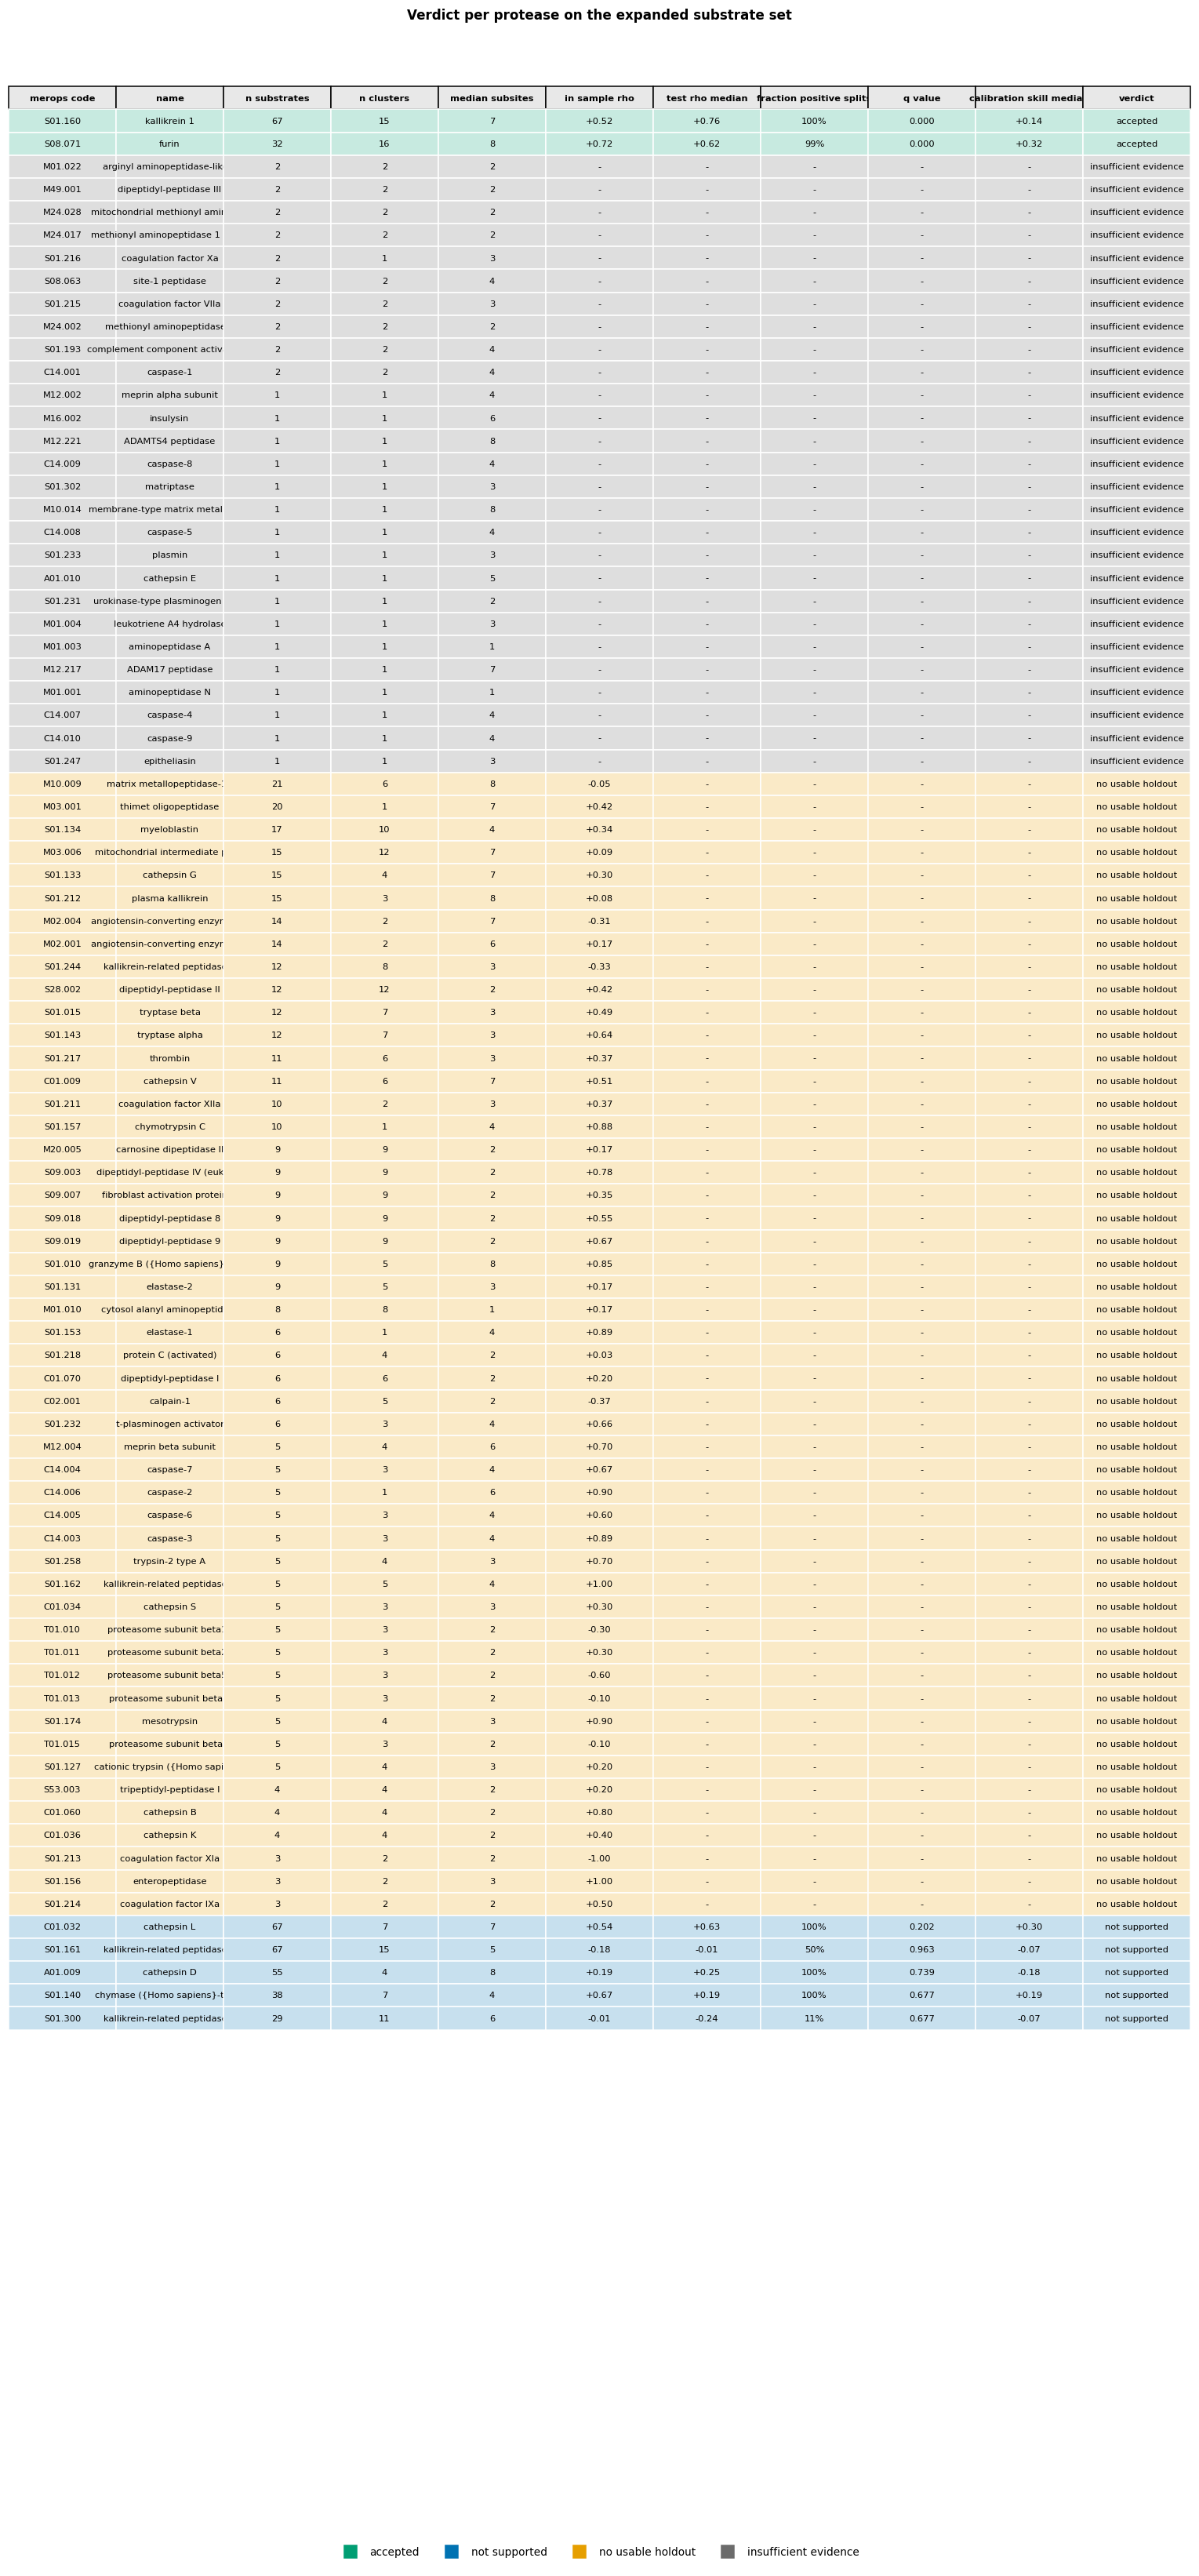

In [13]:
table_rows = verdicts.sort_values(
    ["verdict", "n_substrates"], ascending=[True, False]
).reset_index(drop=True)
display_columns = [
    "merops_code", "name", "n_substrates", "n_clusters", "median_subsites",
    "in_sample_rho", "test_rho_median", "fraction_positive_splits", "q_value",
    "calibration_skill_median", "verdict",
]

fig, ax = plt.subplots(figsize=(14.0, 0.34 * len(table_rows) + 1.4))
ax.axis("off")
cell_text = []
for _, row in table_rows.iterrows():
    cell_text.append(
        [
            str(row["merops_code"]),
            str(row["name"])[:32],
            f"{int(row['n_substrates'])}",
            f"{int(row['n_clusters'])}",
            f"{row['median_subsites']:.0f}",
            "-" if not np.isfinite(row["in_sample_rho"]) else f"{row['in_sample_rho']:+.2f}",
            "-" if not np.isfinite(row["test_rho_median"]) else f"{row['test_rho_median']:+.2f}",
            "-" if not np.isfinite(row["fraction_positive_splits"]) else f"{row['fraction_positive_splits']:.0%}",
            "-" if not np.isfinite(row["q_value"]) else f"{row['q_value']:.3f}",
            "-" if not np.isfinite(row["calibration_skill_median"]) else f"{row['calibration_skill_median']:+.2f}",
            str(row["verdict"]).replace("_", " "),
        ]
    )

table = ax.table(
    cellText=cell_text,
    colLabels=[column.replace("_", " ") for column in display_columns],
    cellLoc="center",
    loc="upper center",
)
table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.scale(1, 1.25)

## REMARK: The verdict colour is applied as a light row tint rather than to the
## text, so that the numbers keep their normal ink and stay readable.
def _tint(colour: str, weight: float = 0.22) -> tuple[float, float, float]:
    """Blend a verdict colour towards white for use as a row background.

    :param colour: Matplotlib colour of the verdict.
    :param weight: Share of the verdict colour in the blend.
    :return: RGB tuple.
    """

    rgb = np.array(mcolors.to_rgb(colour))
    return tuple(1.0 - weight * (1.0 - rgb))


for column in range(len(display_columns)):
    header = table[0, column]
    header.set_facecolor("#e8e8e8")
    header.set_text_props(fontweight="bold")
for position, row in table_rows.iterrows():
    tint = _tint(verdict_colour[row["verdict"]])
    for column in range(len(display_columns)):
        cell = table[position + 1, column]
        cell.set_facecolor(tint)
        cell.set_edgecolor("white")
ax.set_title(
    "Verdict per protease on the expanded substrate set", fontsize=11, fontweight="bold", pad=14
)
handles = [
    plt.Line2D([], [], marker="s", linestyle="", markersize=10, color=colour,
               label=verdict.replace("_", " "))
    for verdict, colour in verdict_colour.items()
    if verdict in set(table_rows["verdict"])
]
ax.legend(handles=handles, loc="lower center", ncol=len(handles), fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

In [14]:
destination = common.save_result(verdicts, f"{PREFIX}_per_protease_verdicts.csv")
common.save_result(split_table, f"{PREFIX}_substrate_splits.csv")
print()
print(f"written: {destination.relative_to(common.ROOT)}")
verdicts[["merops_code", "name", "n_substrates", "test_rho_median", "fraction_positive_splits", "q_value", "verdict"]]


written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_04_per_protease_verdicts.csv


,merops_code,name,n_substrates,test_rho_median,fraction_positive_splits,q_value,verdict
0,C01.032,cathepsin L,67,0.627621,1.0,0.202222,not_supported
1,S01.160,kallikrein 1,67,0.755781,1.0,0.000000,accepted
2,S01.161,kallikrein-related peptidase 2,67,-0.009402,0.5,0.963333,not_supported
3,A01.009,cathepsin D,55,0.246885,1.0,0.738889,not_supported
4,S01.140,chymase ({Homo sapiens}-type),38,0.187879,1.0,0.676667,not_supported
...,...,...,...,...,...,...,...
79,M12.217,ADAM17 peptidase,1,NaN,NaN,NaN,insufficient_evidence
80,M01.001,aminopeptidase N,1,NaN,NaN,NaN,insufficient_evidence
81,C14.007,caspase-4,1,NaN,NaN,NaN,insufficient_evidence
82,C14.010,caspase-9,1,NaN,NaN,NaN,insufficient_evidence


## What the extension brought in, and what it changed

A protease in this table is either one the baseline scope already had or one the
extension brought in, and for the first kind the interesting quantity is not its
verdict but **how its verdict moved**. Both are marked explicitly rather than left
to a reader holding two tables side by side.

* **★** marks a protease that exists only because of the extension. It has no
  baseline verdict to improve on, so its contribution is coverage.
* **↑ / ↓ / =** marks how a protease already present in the baseline moved, on the
  ordered scale `insufficient_evidence` < `no_usable_holdout` < `not_supported` <
  `accepted`, together with the change in its held-out correlation.

The distinction matters because the two are different kinds of gain. New proteases
widen what the model covers; moved proteases say whether more substrates made the
existing evidence better or merely more abundant.

In [15]:
baseline_verdicts = pd.read_csv(common.RESULTS_ROOT / "2_02_per_protease_verdicts.csv")

# Ordered so that a change of state has a direction. A protease with too few
# substrates to evaluate ranks below one that was evaluated and failed, because the
# second carries a result and the first carries none.
VERDICT_ORDER = ["insufficient_evidence", "no_usable_holdout", "not_supported", "accepted"]
RANK_OF = {name: rank for rank, name in enumerate(VERDICT_ORDER)}

extension = verdicts.merge(
    baseline_verdicts[["merops_code", "verdict", "test_rho_median", "n_substrates"]],
    on="merops_code", how="left", suffixes=("", "_baseline"),
)
extension["is_new"] = extension["verdict_baseline"].isna()
extension["verdict_rank"] = extension["verdict"].map(RANK_OF)
extension["verdict_rank_baseline"] = extension["verdict_baseline"].map(RANK_OF)
extension["verdict_shift"] = extension["verdict_rank"] - extension["verdict_rank_baseline"]
extension["rho_shift"] = extension["test_rho_median"] - extension["test_rho_median_baseline"]
extension["substrates_gained"] = extension["n_substrates"] - extension["n_substrates_baseline"]

## The marker a reader scans for
def marker(row: pd.Series) -> str:
    """Return the symbol summarising what the extension did to one protease."""
    if row["is_new"]:
        return "*"
    if not np.isfinite(row["verdict_shift"]) or row["verdict_shift"] == 0:
        return "="
    return "^" if row["verdict_shift"] > 0 else "v"


extension["change"] = extension.apply(marker, axis=1)
extension["label"] = extension["change"] + " " + extension["merops_code"]

summary = pd.DataFrame(
    {
        "state": ["* new with the extension", "^ verdict improved", "= verdict unchanged", "v verdict worsened"],
        "proteases": [
            int((extension["change"] == "*").sum()),
            int((extension["change"] == "^").sum()),
            int((extension["change"] == "=").sum()),
            int((extension["change"] == "v").sum()),
        ],
    }
)
print(summary.to_string(index=False))
print()
print(f"proteases carried over from the baseline: {int((~extension['is_new']).sum())}")
carried = extension[~extension["is_new"]]
if len(carried):
    print(f"  median substrates gained: {carried['substrates_gained'].median():.0f}")
    print(f"  median change in held-out correlation: {carried['rho_shift'].median():+.3f}")
    print(f"  improved their correlation: {int((carried['rho_shift'] > 0).sum())} of {len(carried)}")

print()
print("proteases whose verdict moved:")
moved = extension[extension["change"].isin(["^", "v"])]
print(
    moved[["label", "name", "verdict_baseline", "verdict", "n_substrates_baseline", "n_substrates", "rho_shift"]]
    .round(3).to_string(index=False)
    if len(moved) else "  none"
)

                   state  proteases
* new with the extension         60
      ^ verdict improved          0
     = verdict unchanged         24
      v verdict worsened          0

proteases carried over from the baseline: 24
  median substrates gained: 0
  median change in held-out correlation: +0.000
  improved their correlation: 1 of 24

proteases whose verdict moved:
  none


### Reading the figure

Every protease of the extended panel, ordered by held-out correlation. A star marks
one the extension brought in; an arrow marks one already present whose verdict
moved, with the tail at its baseline correlation. A panel made mostly of stars has
gained coverage; one made mostly of long arrows has gained evidence on what it
already had.

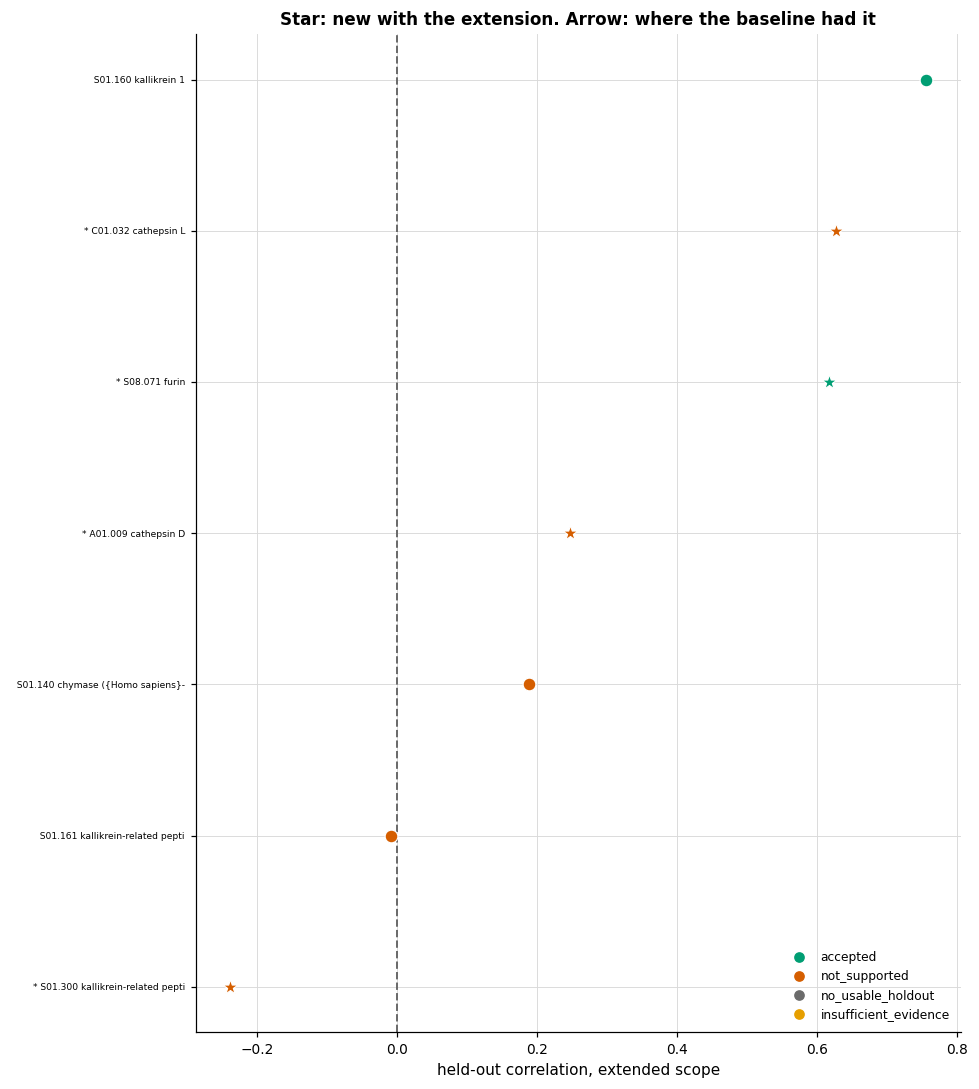

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_04_extension_effect.csv')

In [16]:
fig, ax = plt.subplots(figsize=(9.0, 10.0))
ordered = extension.dropna(subset=["test_rho_median"]).sort_values("test_rho_median").reset_index(drop=True)
colour_of = {
    "accepted": common.CATEGORICAL_COLORS[2],
    "not_supported": common.CATEGORICAL_COLORS[1],
    "no_usable_holdout": common.NEUTRAL,
    "insufficient_evidence": common.CATEGORICAL_COLORS[3],
}
for position, row in enumerate(ordered.itertuples()):
    colour = colour_of.get(row.verdict, common.NEUTRAL)
    ## An arrow from where the baseline had it to where the extension puts it
    if not row.is_new and np.isfinite(row.test_rho_median_baseline):
        ax.annotate(
            "", xy=(row.test_rho_median, position), xytext=(row.test_rho_median_baseline, position),
            arrowprops=dict(arrowstyle="->", color=common.NEUTRAL, linewidth=1.0, alpha=0.8),
        )
    ax.scatter(row.test_rho_median, position, s=110 if row.is_new else 70,
               marker="*" if row.is_new else "o", color=colour,
               edgecolor="white", linewidth=0.8, zorder=4)
ax.axvline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.3)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(
    [f"{'*' if row.is_new else ' '} {row.merops_code} {str(row.name)[:24]}" for row in ordered.itertuples()],
    fontsize=6,
)
ax.set_xlabel("held-out correlation, extended scope")
ax.set_title("Star: new with the extension. Arrow: where the baseline had it")
handles = [
    plt.Line2D([], [], marker="o", linestyle="none", color=colour, label=verdict)
    for verdict, colour in colour_of.items()
]
ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

common.save_result(extension, "2_04_extension_effect.csv")

> **Caveat.** The extension comparison reads `results/2_02_per_protease_verdicts.csv` and reuses the expanded rows produced by `2_06`. An apparent increase in accepted proteases can result from added `quenched` substrates whose bond is selected by the same MEROPS matrix being evaluated. Compare `reporter` and `quenched` verdicts separately and account for shared EC measurements before treating the change as independent validation.


## What the extension actually bought

**The extension is pure coverage. It adds proteases and changes nothing about the
ones already there.**

| | proteases |
| --- | --- |
| **★** new with the extension | **60** |
| **=** carried over, verdict unchanged | **24** |
| **↑** carried over, verdict improved | **0** |
| **↓** carried over, verdict worsened | **0** |

Not one of the twenty-four proteases the baseline scope already had moved. The
transitions are entirely diagonal: one `accepted` stayed accepted, six
`insufficient_evidence` stayed insufficient, fifteen `no_usable_holdout` stayed
without a usable holdout, two `not_supported` stayed unsupported.

The reason is visible in the substrate counts: the median carried-over protease
gained **zero** substrates, and its held-out correlation moved by **+0.000**. The
serum EC scope is a strict subset of the peptidase scope, so a protease present in
both has the *same* measurements in both. This is the same fact `0_15` reports from
the dataset side, where every row shared between the two datasets carries an
identical label.

**What the sixty new proteases are worth, in validation terms, is one enzyme.**

| verdict | new proteases |
| --- | --- |
| `no_usable_holdout` | 35 |
| `insufficient_evidence` | 21 |
| `not_supported` | 3 |
| **`accepted`** | **1** |

The single acceptance is furin. Fifty-nine of the sixty either could not be
evaluated on held-out clusters or were evaluated and failed.

**How to read that.** The expansion was worth doing and its value is not where a
casual reading would put it. It did not strengthen the existing evidence — it could
not, since it contains the same measurements for those enzymes. It widened the panel
from seventeen proteases to fifty-eight, which is what makes the pooled correlation
of `2_03` a statement about peptidases rather than about the serum subset, and it
produced exactly one more enzyme whose matrix predicts its own kinetics on held-out
substrates.

A reader deciding whether to extend a scope again should expect the same shape of
return: coverage in proportion to the new data, and validated proteases in
proportion to how many of the new enzymes happen to have enough clustered substrates
to hold any out.